In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
import pandas as pd

file_path = r'C:\Users\sbossier\Desktop\lissajous_shape\20221116-0018.csv'

# Load the data
data = pd.read_csv(file_path)

# Display the first few rows of the data
print(data.head())

# Convert units and add new columns to the DataFrame
data_si = data.assign(
    time_s = lambda x: x['time_ms'] / 1000,
    charge_C = lambda x: x['charge_uC'] / 1e6,
    voltage_V = lambda x: x['voltage_kV'] * 1000
)

# Integrate current_plasma_A over time_s to get charge_integrated_C
data_si['charge_integrated_C'] = (data_si['current_plasma_A'] * data_si['time_s'].diff().fillna(0)).cumsum()

# Display the first few rows of the modified data
print(data_si.head())

    time_ms  charge_uC  voltage_kV  current_plasma_A  current_source_mA
0  0.000000  -0.362697   -0.157480          0.007628           17.48031
1  0.000003  -0.362697   -0.137795          0.007751           17.48031
2  0.000006  -0.362697   -0.137795          0.007874           17.48031
3  0.000010  -0.362697   -0.137795          0.007874           17.48031
4  0.000013  -0.362697   -0.137795          0.007874           17.48031
    time_ms  charge_uC  voltage_kV  current_plasma_A  current_source_mA  \
0  0.000000  -0.362697   -0.157480          0.007628           17.48031   
1  0.000003  -0.362697   -0.137795          0.007751           17.48031   
2  0.000006  -0.362697   -0.137795          0.007874           17.48031   
3  0.000010  -0.362697   -0.137795          0.007874           17.48031   
4  0.000013  -0.362697   -0.137795          0.007874           17.48031   

         time_s      charge_C  voltage_V  charge_integrated_C  
0  0.000000e+00 -3.626969e-07  -157.4803         0.00

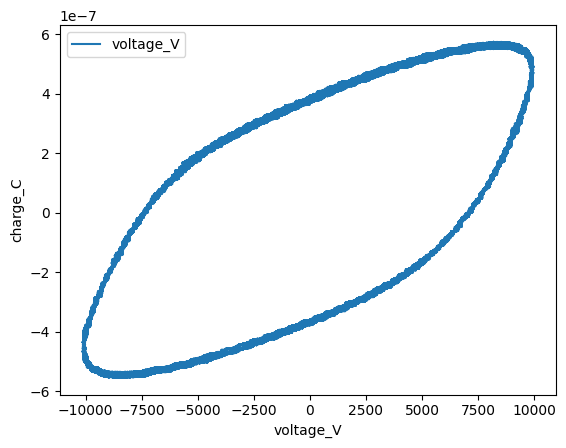

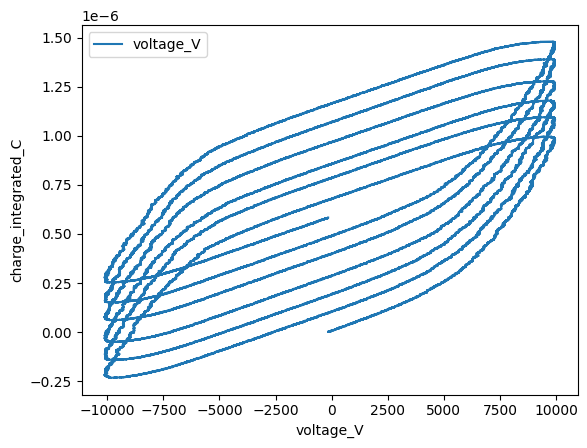

In [10]:
# plot voltage_V vs charge_C and charge_integrated_C
fig, ax = plt.subplots()
ax.plot(data_si['voltage_V'], data_si['charge_C'], label='voltage_V')
ax.set_xlabel('voltage_V')
ax.set_ylabel('charge_C')
ax.legend()

fig, ax = plt.subplots()
ax.plot(data_si['voltage_V'], data_si['charge_integrated_C'], label='voltage_V')
ax.set_xlabel('voltage_V')
ax.set_ylabel('charge_integrated_C')
ax.legend()
